### 데이터 증대(Data Augmentation)
- 한정된 데이터를 여러가지로 변형하여 데이터셋을 확장하는 방법

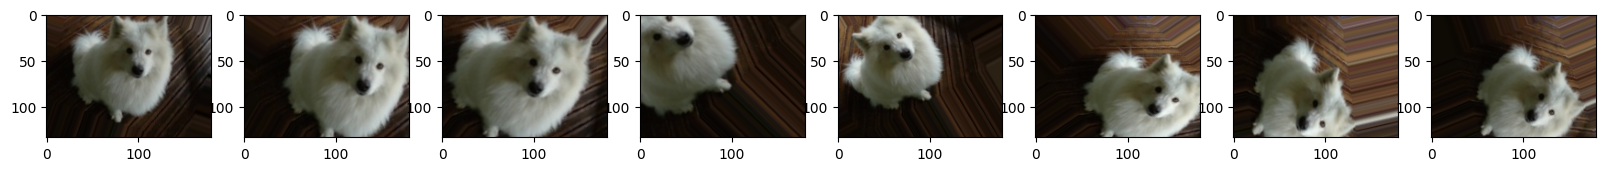

In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt
from numpy import expand_dims
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator

image = load_img('data/dog.jpg')
array = img_to_array(image)
sample = expand_dims(array, axis=0)

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=90, # 회전 범위
    brightness_range=[0.8, 1.0], # 밝기 범위
    width_shift_range=0.2, # 좌우 이동 범위
    zoom_range=[0.8, 1.2], # 확대 범위
    height_shift_range=0.2 # 상하 이동 범위
    )

obj = datagen.flow(sample, batch_size=1) # generator 반환
fig = plt.figure(figsize=(20,5))

for i in range(8):
    plt.subplot(1, 8, i+1)
    image = next(obj)
    plt.imshow(image[0])


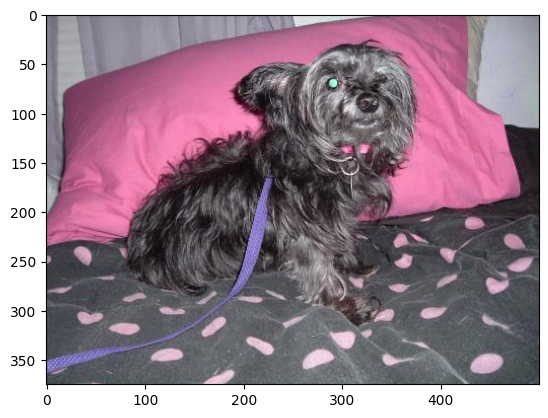

In [1]:
from matplotlib import pyplot
from matplotlib.image import imread

image = imread('data/PetImages/train/dog/0.jpg')
pyplot.imshow(image)
pyplot.show()

Found 1000 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Epoch 1/10
25/25 [==============================] - 5s 174ms/step - loss: 1.4404 - accuracy: 0.4900 - val_loss: 0.6945 - val_accuracy: 0.4300
Epoch 2/10
25/25 [==============================] - 4s 165ms/step - loss: 0.6934 - accuracy: 0.5380 - val_loss: 0.6940 - val_accuracy: 0.5200
Epoch 3/10
25/25 [==============================] - 4s 159ms/step - loss: 0.6915 - accuracy: 0.5500 - val_loss: 0.6772 - val_accuracy: 0.5900
Epoch 4/10
25/25 [==============================] - 4s 171ms/step - loss: 0.6903 - accuracy: 0.5400 - val_loss: 0.6837 - val_accuracy: 0.5800
Epoch 5/10
25/25 [==============================] - 4s 166ms/step - loss: 0.6833 - accuracy: 0.5900 - val_loss: 0.6924 - val_accuracy: 0.5300
Epoch 6/10
25/25 [==============================] - 4s 165ms/step - loss: 0.6651 - accuracy: 0.6160 - val_loss: 0.5922 - val_accuracy: 0.6900
Epoch 7/10
25/25 [==============================] - 4s 164ms/step

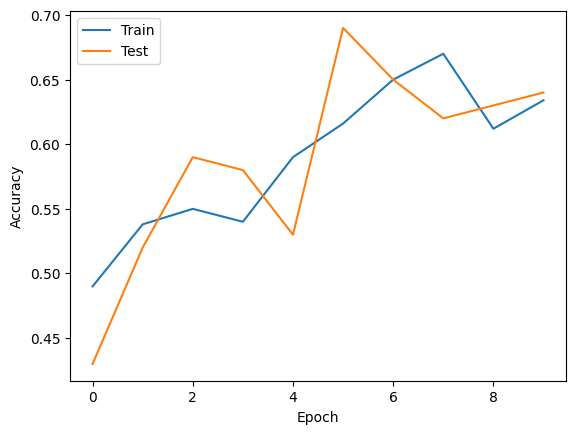

In [5]:
from tensorflow.keras import models, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

train_dir = 'data/PetImages/train'
test_dir = 'data/PetImages/test'

model = models.Sequential()
model.add(layers.Input(shape=(128, 128, 3)))
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Flatten())
model.add(layers.Dense(units=512, activation='relu'))
model.add(layers.Dense(units=1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

train_datagen = ImageDataGenerator(rescale=1./255, shear_range = 0.2, zoom_range=0.2, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=20,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=20,
    class_mode='binary'
)

history = model.fit(
    train_generator, steps_per_epoch=25, epochs=10,
    validation_data=test_generator, validation_steps=5
)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

### 가중치 저장과 불러오기
- 학습된 모델의 가중치를 저장하고, 필요할 때 불러와서 바로 예측에 사용할 수 있다.
- `model.save(NAME)` 로 저장하며, 다음 정보가 저장됨.
    - 신경망 모델의 아키텍처 및 구성
    - 훈련 중에 학습된 모델의 가중치 값
    - 신경망 모델의 컴파일 정보
    - 옵티마이저와 현재 상태(훈련을 중단한 곳에서 다시 시작하기 위해)
- 저장 형식
    - TensorFlow SavedModel 형식
    - 이전 Keras H5 형식
- `model.load_model(NAME)` 로 불러온다.

In [ ]:
import numpy as np
import tensorflow as tf

# 난수로 훈련 예제 생성
test_input = np.random.random((128, 32))
test_target = np.random.random((128, 1))

inputs = tf.keras.Input(shape=(32,))
outputs = tf.keras.layers.Dense(1)(inputs)
model = tf.keras.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(test_input, test_target, epochs=3)

# 한글이 포함된 경로는 인식 못함
model.save('C:/Users/0627j/dl_test/my_model')

saved_model = tf.keras.models.load_model('C:/Users/0627j/dl_test/my_model')

saved_model.fit(test_input, test_target, epochs=3)

Epoch 1/3
4/4 [==============================] - 0s 3ms/step - loss: 0.5338
Epoch 2/3
4/4 [==============================] - 0s 0s/step - loss: 0.4733
Epoch 3/3
4/4 [==============================] - 0s 3ms/step - loss: 0.4163


INFO:tensorflow:Assets written to: C:/Users/0627j/dl_test/my_model\assets


INFO:tensorflow:Assets written to: C:/Users/0627j/dl_test/my_model\assets


Epoch 1/3
4/4 [==============================] - 0s 1ms/step - loss: 0.3697
Epoch 2/3
4/4 [==============================] - 0s 2ms/step - loss: 0.3323
Epoch 3/3
4/4 [==============================] - 0s 0s/step - loss: 0.3069


### 전이 학습
- 사전 학습된 신경망 모델을 다른 용도로 사용하는 것
- <img src='img/zy.png' width=600>

#### Keras Applocations
- 케라스에서 제공하는 사전 훈련된 딥러닝 모델들
- <img src='img/zz.png' width=400>
- Top n 정확도: 예측한 n개 후보 안에 정답이 포함되 있는 비율

#### 사전 훈련된 모델을 프로젝트에 맞게 재정의
- <img src='img/zza.png' width=400>

In [6]:
# 모델을 변경 없이 그대로 쓰기
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

model = ResNet50(weights='imagenet') # ResNet50이 학습한 ImageNet 데이터셋에 대한 가중치를 가져옴

img_path = 'data/dog.jpg'
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img) # 이미지를 넘파이 배열로 변환
x = np.expand_dims(x, axis=0)
# 차원을 하나 늘린다.
# 인공지능은 사진 한장을 처리할 때도 여러장의 사진 묶음(배치) 형태로 받기 원함.
# 즉, (224, 224, 3) 에서 (1, 224, 224, 3)으로 변환한다.
x = preprocess_input(x) # Resnet50이 요구하는 전처리 작업

preds=model.predict(x)
print('예측: ', decode_predictions(preds, top=3)[0])

1/1 [==============================] - 1s 518ms/step
예측:  [('n02111889', 'Samoyed', 0.9827656), ('n02114548', 'white_wolf', 0.009100926), ('n02112018', 'Pomeranian', 0.0034529255)]


In [14]:
# 모델에 커스텀 분류기 레이어를 붙여서 새로운 신경망 만들고 가지고 있는 이미지로 학습

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = MobileNet(weights='imagenet', include_top=False)
# include_top : 최종 분류기(MobileNet의 사물 분류 부분은 때고 이미지를 분석하는 몸통만 빼서 가져옴, 개/고양이 2가지만 분류하는 새로운 top을 붙이기 위함.)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
preds = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=preds)

for layer in model.layers[:20]:
    layer.trainable = False
for layer in model.layers[20:]:
    layer.trainable = True

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory('data/Petimages/', target_size=(128, 128), color_mode='rgb', batch_size=32, class_mode='categorical', shuffle=True)

model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

step_size_train = train_generator.n // train_generator.batch_size
model.fit(train_generator, steps_per_epoch=step_size_train, epochs=5)

Found 1200 images belonging to 2 classes.
Epoch 1/5
37/37 [==============================] - 13s 294ms/step - loss: 0.6153 - accuracy: 0.8185
Epoch 2/5
37/37 [==============================] - 11s 293ms/step - loss: 0.3731 - accuracy: 0.8373
Epoch 3/5
37/37 [==============================] - 11s 292ms/step - loss: 0.2842 - accuracy: 0.8801
Epoch 4/5
37/37 [==============================] - 11s 290ms/step - loss: 0.2723 - accuracy: 0.9101
Epoch 5/5
37/37 [==============================] - 11s 299ms/step - loss: 0.1993 - accuracy: 0.9229
